In [2]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord 
from astropy import units as u
from astropy.modeling import models, fitting

from dust_extinction.averages import CT06_MWGC 

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from icemodels.colorcolordiagrams import plot_ccd_icemodels
from smart_plotters import cmd_plot 
from sklearn.mixture import GaussianMixture
from mpl_plot_templates import adaptive_param_plot
from scipy.optimize import curve_fit 
from scipy.signal import find_peaks, argrelextrema

from reproject import reproject_interp

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
/blue/adamginsburg/adamginsburg/repos/jwst-gc-pipeline/jwst_gc_pipeline/plotting/plot_tools.py:1050: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
/blue/adamginsburg/adamginsburg/repos/jwst-gc-pipeline/jwst_gc_pipeline/plotting/plot_tools.py:1050: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [3]:
def get_rc_sel_mask(cat):
    x = np.linspace(0, 2.5, 10)
    
    x0 = 0.52
    mask_x0_left = cat.color('f182m', 'f212n') > x0

    y0 = 14.8
    mask_above_y0 = cat.band('f182m') > y0
    mask_rc = mask_above_y0 & mask_x0_left

    pt1 = (0.5, 14.3)
    pt2 = (2.0, 20.)
    y1 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_below_y1 = cat.band('f182m') > ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_below_y1 & mask_rc

    pt1 = (0.5, 15.5)
    pt2 = (2.0, 20.9)
    y2 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_above_y2 = cat.band('f182m') < ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_rc & mask_above_y2

    return mask_rc

In [4]:
cat_brick = make_brick_cat()
cat_brick.catalog['Av'] = cat_brick.get_Av('f182m', 'f212n')
cat_brick.catalog['N(CO)'] = co_map.get_co_ice_column(cat_brick, cat_brick.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

Reading /orange/adamginsburg/jwst/brick/catalogs/final/basic_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits


In [5]:
cat_brick_rc = JWSTCatalog(cat_brick.catalog[get_rc_sel_mask(cat_brick)])

(22.0, 14.0)

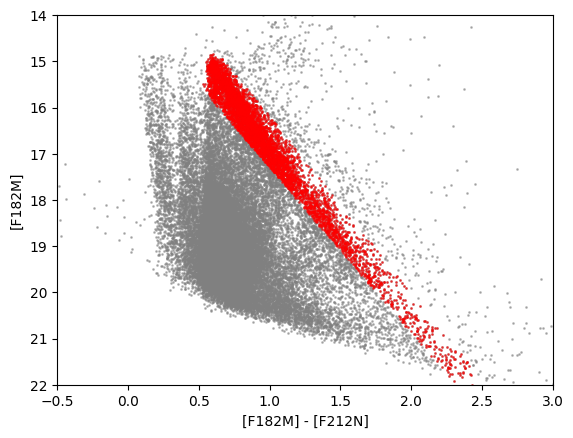

In [6]:
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1)
cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)

In [7]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')


In [9]:
fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
hdu_brick = fits.open(fn_brick)
ww_brick = WCS(hdu_brick['SCI'].header)
nanfield_brick = np.nan * hdu_brick['SCI'].data

In [10]:
cat_brick_north = JWSTCatalog(cat_brick.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south = JWSTCatalog(cat_brick.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head = JWSTCatalog(cat_brick.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_sfrwide = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfrwide, ww_brick))
cat_brick_punch = JWSTCatalog(cat_brick.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nclear, ww_brick))
cat_brick_topc = JWSTCatalog(cat_brick.table_region_mask(reg_brick_topc, ww_brick))


In [11]:
g0253_absorption_core = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/g0253_absorption_core.reg', format='ds9')

In [12]:
cat_core = JWSTCatalog(cat_brick.table_region_mask(g0253_absorption_core, ww_brick))

(22.0, 14.0)

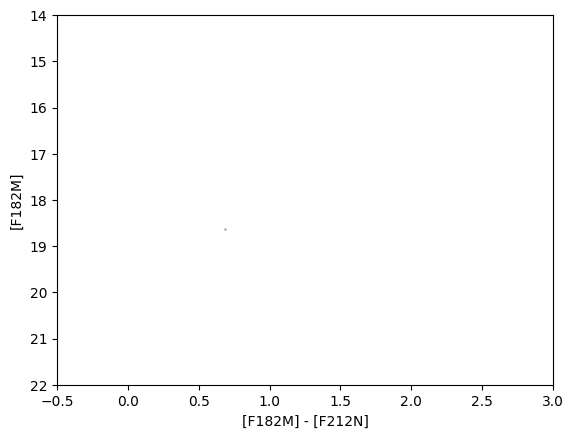

In [13]:
cat_core.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1)
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)

In [14]:
hdu_filaments = fits.open('/orange/adamginsburg/jwst/cloudc/images/g0253_structure8_CO_moment0_v18.18_36.76.fits')

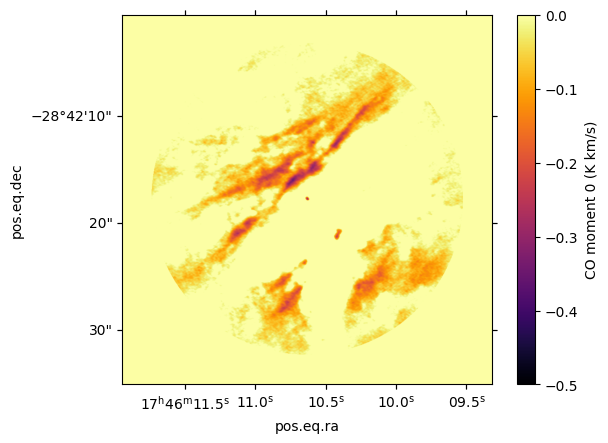

In [15]:
ax = plt.subplot(projection=WCS(hdu_filaments[0].header))
im = ax.imshow(hdu_filaments[0].data, origin='lower', cmap='inferno', vmin=-0.5, vmax=0)
plt.colorbar(im, ax=ax, label='CO moment 0 (K km/s)')

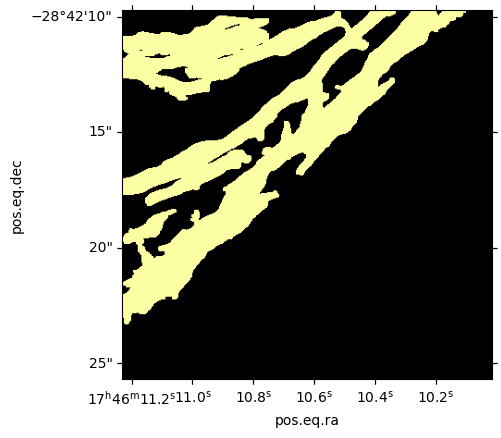

In [16]:
hdu_mask_filament = fits.open('/orange/adamginsburg/jwst/cloudc/images/g0253_structure8_mask_2d.fits')
ww_mask_filament = WCS(hdu_mask_filament[0].header)
ax = plt.subplot(projection=ww_mask_filament)
im = ax.imshow(hdu_mask_filament[0].data, origin='lower', cmap='inferno', vmin=0, vmax=1)
#plt.colorbar(im, ax=ax, label='Mask')

In [17]:
hdu_mask_filament_reproj,_ = reproject_interp((hdu_mask_filament[0].data, ww_mask_filament), ww_brick, shape_out=hdu_brick['SCI'].data.shape)


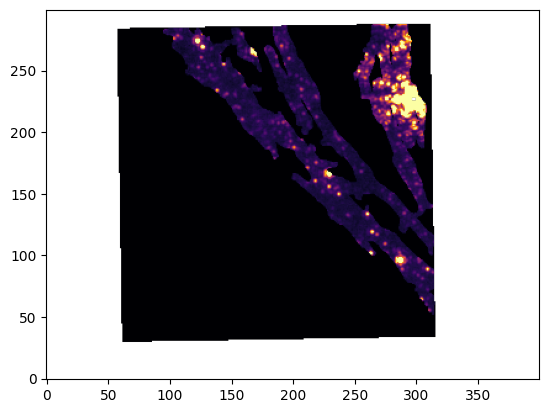

In [18]:
brick_masked = np.copy(hdu_brick['SCI'].data)*hdu_mask_filament_reproj
plt.imshow(brick_masked[1450:1750, 3100:3500], origin='lower', cmap='inferno', vmin=0, vmax=50)

In [19]:
# identify stars in the filament mask
spatial_mask = hdu_mask_filament[0].data
coords_pix = ww_mask_filament.world_to_pixel(cat_brick.catalog['skycoord_ref'])

# remove indexes that are less than 0 or greater than the shape of the mask
valid_x = (coords_pix[0] >= 0) & (coords_pix[0] < spatial_mask.shape[1])
valid_y = (coords_pix[1] >= 0) & (coords_pix[1] < spatial_mask.shape[0])
valid_coords = valid_x & valid_y

coords_pix_valid = coords_pix[0][valid_coords], coords_pix[1][valid_coords]
cat_brick_valid = cat_brick.catalog[valid_coords]

cat_pix_rounded = np.round(coords_pix_valid).astype(int)
mask_stars_in_filament = spatial_mask[cat_pix_rounded[1], cat_pix_rounded[0]] > 0

cat_brick_valid = JWSTCatalog(cat_brick_valid[mask_stars_in_filament])

In [20]:
area_contour = np.sum(spatial_mask) * ww_mask_filament.proj_plane_pixel_area().to(u.arcsec**2)
dens = np.sum(mask_stars_in_filament)/area_contour
print(f"Density of stars in filament mask: {dens.value:.2e} stars/arcsec^2")

Density of stars in filament mask: 1.67e+00 stars/arcsec^2


In [21]:
area_contour

<Quantity 60.2992 arcsec2>

<WCSAxes: >

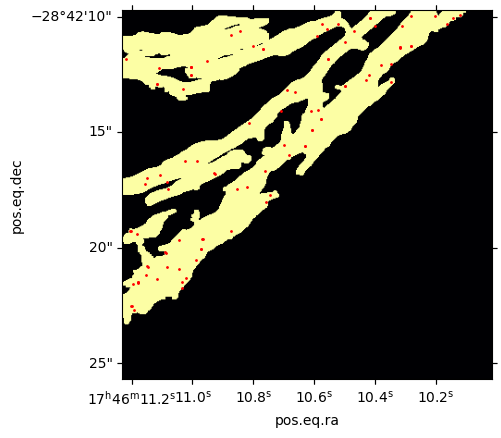

In [22]:
hdu_mask_filament = fits.open('/orange/adamginsburg/jwst/cloudc/images/g0253_structure8_mask_2d.fits')
ww_mask_filament = WCS(hdu_mask_filament[0].header)
ax = plt.subplot(projection=ww_mask_filament)
im = ax.imshow(hdu_mask_filament[0].data, origin='lower', cmap='inferno', vmin=0, vmax=1)
cat_brick_valid.plot_position(transform=ax.get_transform('world'), color='red', alpha=1, s=1)
#plt.colorbar(im, ax=ax, label='Mask')

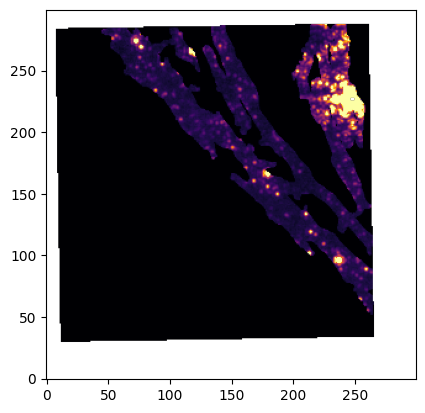

In [23]:
brick_masked = np.copy(hdu_brick['SCI'].data)*hdu_mask_filament_reproj
plt.imshow(brick_masked[1450:1750, 3150:3450], origin='lower', cmap='inferno', vmin=0, vmax=50)


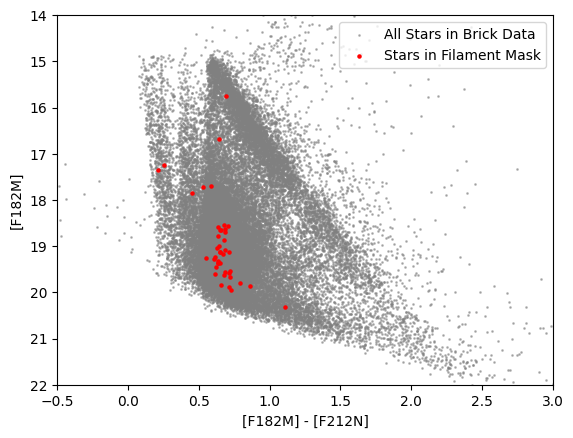

In [24]:
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
cat_brick_valid.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=1, s=5, label='Stars in Filament Mask')
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)
#plt.axvline(0.57, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

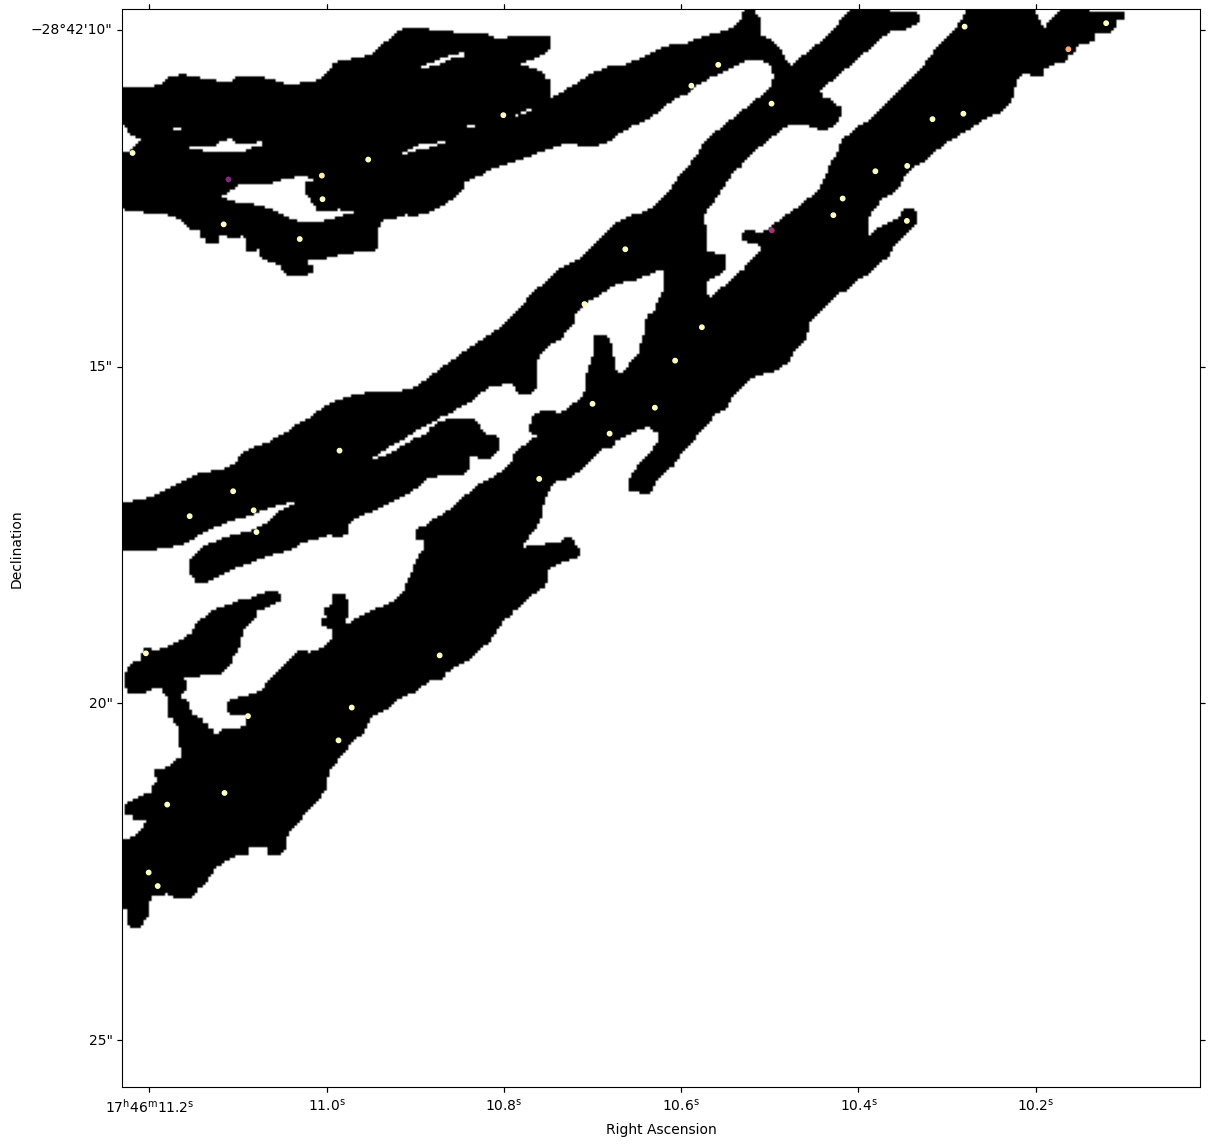

In [25]:
hdu_mask_filament = fits.open('/orange/adamginsburg/jwst/cloudc/images/g0253_structure8_mask_2d.fits')
ww_mask_filament = WCS(hdu_mask_filament[0].header)

fig = plt.figure(figsize=(14, 14))
ax = plt.subplot(111, projection=ww_mask_filament)
im = ax.imshow(hdu_mask_filament[0].data, origin='lower', cmap='Greys', vmin=0, vmax=1)
cat_brick_valid.plot_position(transform=ax.get_transform('world'), c=cat_brick_valid.color('f182m', 'f212n'), alpha=1, s=10, vmin=0, vmax=0.55, cmap='magma')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')


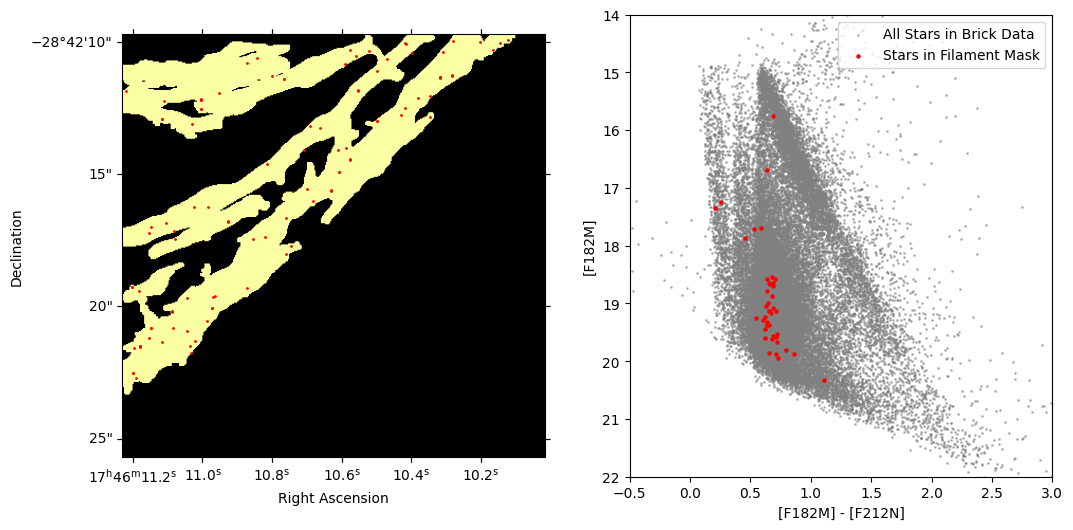

In [26]:
hdu_mask_filament = fits.open('/orange/adamginsburg/jwst/cloudc/images/g0253_structure8_mask_2d.fits')
ww_mask_filament = WCS(hdu_mask_filament[0].header)

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(121, projection=ww_mask_filament)
im = ax.imshow(hdu_mask_filament[0].data, origin='lower', cmap='inferno', vmin=0, vmax=1)
cat_brick_valid.plot_position(transform=ax.get_transform('world'), color='red', alpha=1, s=1)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

ax2 = plt.subplot(122)
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, label='All Stars in Brick Data', ax=ax2)
cat_brick_valid.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=1, s=5, label='Stars in Filament Mask', ax=ax2)
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)
#plt.axvline(0.57, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

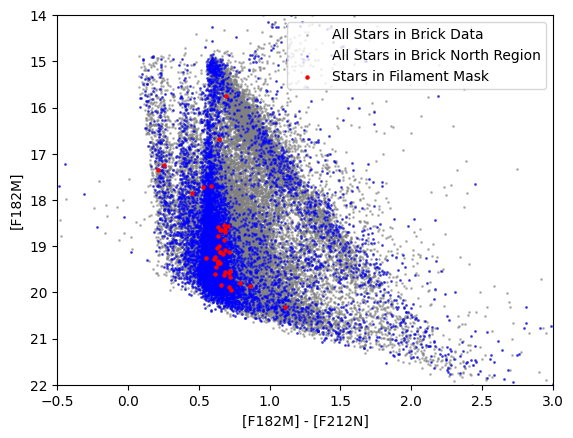

In [27]:
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
cat_brick_north.plot_CMD('f182m', 'f212n', 'f182m', color='blue', alpha=0.5, s=1, label='All Stars in Brick North Region')
#cat_brick_south.plot_CMD('f182m', 'f212n', 'f182m', color='green', alpha=0.5, s=1, label='All Stars in Brick South Region')
#cat_brick_sfr.plot_CMD('f182m', 'f212n', 'f182m', color='orange', alpha=0.5, s=1, label='All Stars in SFR Region')
cat_brick_valid.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=1, s=5, label='Stars in Filament Mask')
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)
#plt.axvline(0.58, color='black', linestyle='--', alpha=0.5)
#plt.axvline(0.7, color='black', linestyle='--', alpha=0.5)
#plt.axvline(0.75, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

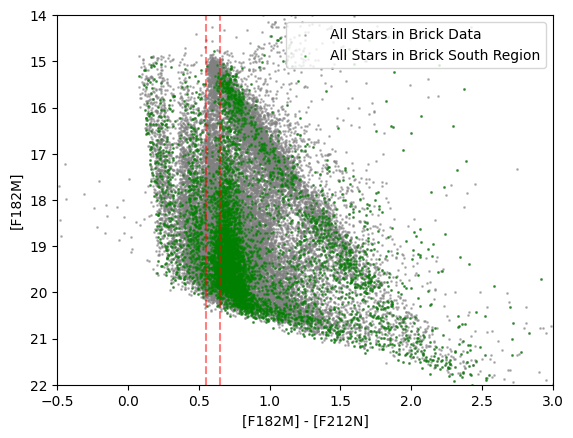

In [28]:
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
#cat_brick_north.plot_CMD('f182m', 'f212n', 'f182m', color='blue', alpha=0.5, s=1, label='All Stars in Brick North Region')
cat_brick_south.plot_CMD('f182m', 'f212n', 'f182m', color='green', alpha=0.5, s=1, label='All Stars in Brick South Region')
#cat_brick_sfr.plot_CMD('f182m', 'f212n', 'f182m', color='orange', alpha=0.5, s=1, label='All Stars in SFR Region')
#cat_brick_valid.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=1, s=5, label='Stars in Filament Mask')
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)
#plt.axvline(0.58, color='black', linestyle='--', alpha=0.5)
#plt.axvline(0.33, color='black', linestyle='--', alpha=0.5)
#plt.axvline(0.45, color='black', linestyle='--', alpha=0.5)
plt.axvline(0.55, color='red', linestyle='--', alpha=0.5)
plt.axvline(0.65, color='red', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

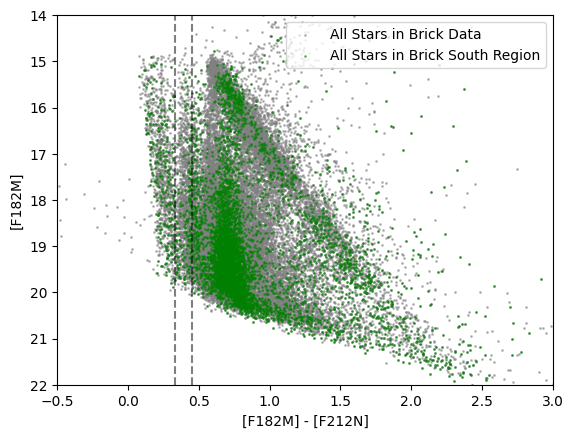

In [29]:
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
#cat_brick_north.plot_CMD('f182m', 'f212n', 'f182m', color='blue', alpha=0.5, s=1, label='All Stars in Brick North Region')
cat_brick_south.plot_CMD('f182m', 'f212n', 'f182m', color='green', alpha=0.5, s=1, label='All Stars in Brick South Region')
#cat_brick_sfr.plot_CMD('f182m', 'f212n', 'f182m', color='orange', alpha=0.5, s=1, label='All Stars in SFR Region')
#cat_brick_valid.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=1, s=5, label='Stars in Filament Mask')
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)
#plt.axvline(0.58, color='black', linestyle='--', alpha=0.5)
plt.axvline(0.33, color='black', linestyle='--', alpha=0.5)
plt.axvline(0.45, color='black', linestyle='--', alpha=0.5)
#plt.axvline(0.55, color='red', linestyle='--', alpha=0.5)
#plt.axvline(0.65, color='red', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

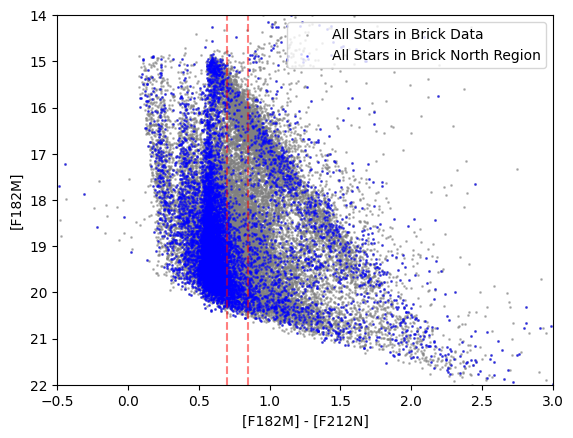

In [30]:
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
cat_brick_north.plot_CMD('f182m', 'f212n', 'f182m', color='blue', alpha=0.5, s=1, label='All Stars in Brick North Region')
#cat_brick_south.plot_CMD('f182m', 'f212n', 'f182m', color='green', alpha=0.5, s=1, label='All Stars in Brick South Region')
#cat_brick_sfr.plot_CMD('f182m', 'f212n', 'f182m', color='orange', alpha=0.5, s=1, label='All Stars in SFR Region')
#cat_brick_valid.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=1, s=5, label='Stars in Filament Mask')
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)
#plt.axvline(0.58, color='black', linestyle='--', alpha=0.5)
#plt.axvline(0.33, color='black', linestyle='--', alpha=0.5)
#plt.axvline(0.45, color='black', linestyle='--', alpha=0.5)
plt.axvline(0.7, color='red', linestyle='--', alpha=0.5)
plt.axvline(0.85, color='red', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

In [31]:
fore_brick_all = JWSTCatalog(cat_brick.catalog[np.logical_and(cat_brick.color('f182m', 'f212n') > 0.33, cat_brick.color('f182m', 'f212n') < 0.45)])
cmz_brick_all = JWSTCatalog(cat_brick.catalog[np.logical_and(cat_brick.color('f182m', 'f212n') > 0.55, cat_brick.color('f182m', 'f212n') < 0.65)])
deep_brick_all = JWSTCatalog(cat_brick.catalog[np.logical_and(cat_brick.color('f182m', 'f212n') > 0.7, cat_brick.color('f182m', 'f212n') < 0.85)])

NameError: name 'fore_brick_south' is not defined

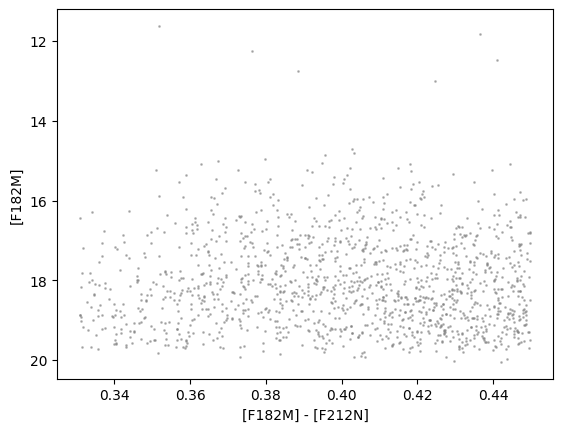

In [32]:
fore_brick_all.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
#cat_brick_north.plot_CMD('f182m', 'f212n', 'f182m', color='blue', alpha=0.5, s=1, label='All Stars in Brick North Region')
fore_brick_south.plot_CMD('f182m', 'f212n', 'f182m', color='green', alpha=0.5, s=1, label='All Stars in Brick South Region')
#cat_brick_sfr.plot_CMD('f182m', 'f212n', 'f182m', color='orange', alpha=0.5, s=1, label='All Stars in SFR Region')
#cat_brick_valid.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=1, s=5, label='Stars in Filament Mask')
#cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)
#plt.axvline(0.58, color='black', linestyle='--', alpha=0.5)
plt.axvline(0.33, color='black', linestyle='--', alpha=0.5)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

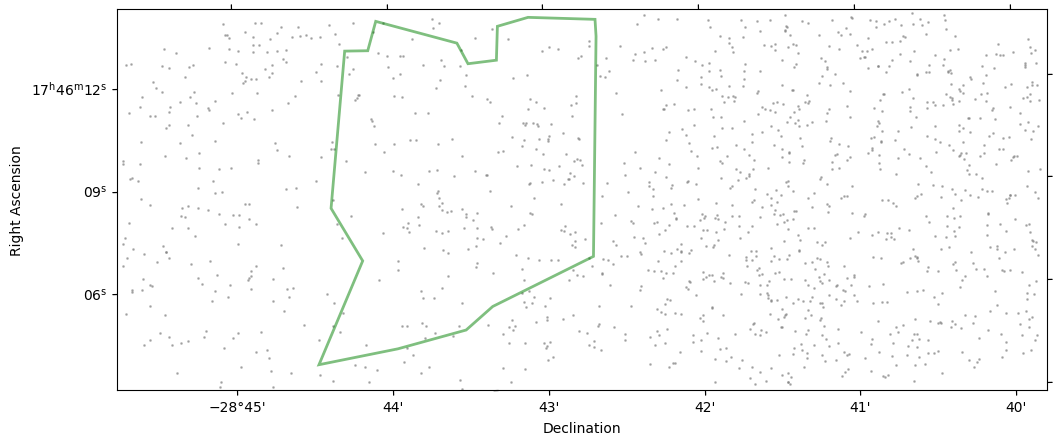

In [33]:
# fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
# hdu_brick = fits.open(fn_brick)
# ww_brick = WCS(hdu_brick['SCI'].header)
# nanfield_brick = np.nan * hdu_brick['SCI'].data

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection=ww_brick)
ax.imshow(nanfield_brick, origin='lower')
fore_brick_all.plot_position(transform=ax.get_transform('world'), color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
reg_brick_south[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='green', lw=2, alpha=0.5, label='Brick South Region')
ax.set_xlabel('Declination')
ax.set_ylabel('Right Ascension')

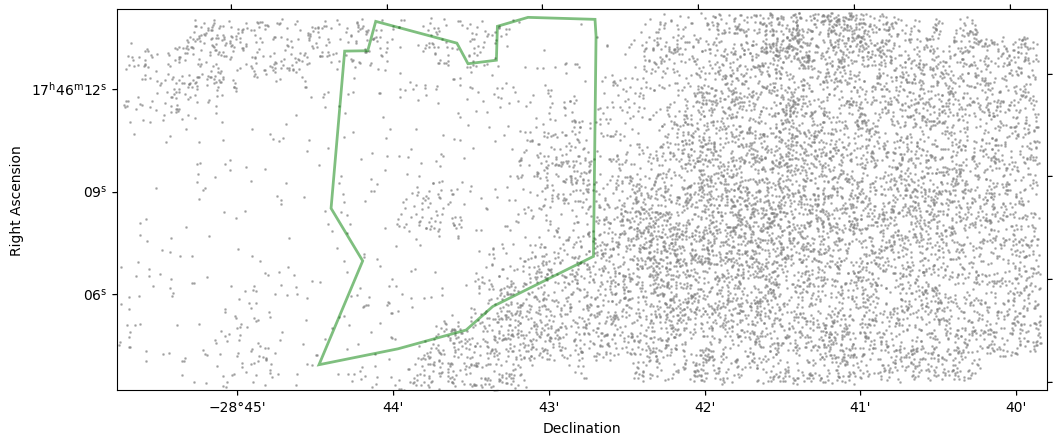

In [34]:
# fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
# hdu_brick = fits.open(fn_brick)
# ww_brick = WCS(hdu_brick['SCI'].header)
# nanfield_brick = np.nan * hdu_brick['SCI'].data

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection=ww_brick)
ax.imshow(nanfield_brick, origin='lower')
cmz_brick_all.plot_position(transform=ax.get_transform('world'), color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
reg_brick_south[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='green', lw=2, alpha=0.5, label='Brick South Region')
ax.set_xlabel('Declination')
ax.set_ylabel('Right Ascension')

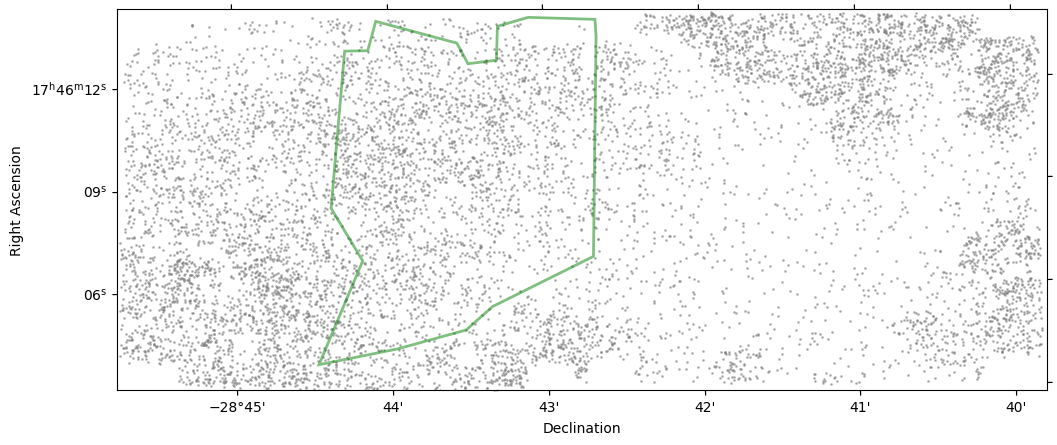

In [35]:
# fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
# hdu_brick = fits.open(fn_brick)
# ww_brick = WCS(hdu_brick['SCI'].header)
# nanfield_brick = np.nan * hdu_brick['SCI'].data

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection=ww_brick)
ax.imshow(nanfield_brick, origin='lower')
deep_brick_all.plot_position(transform=ax.get_transform('world'), color='grey', alpha=0.5, s=1, label='All Stars in Brick Data')
reg_brick_south[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='green', lw=2, alpha=0.5, label='Brick South Region')
ax.set_xlabel('Declination')
ax.set_ylabel('Right Ascension')

In [36]:
def star_density_color(tbl, ww, dx=1*u.arcsec, size=(2.6*u.arcmin, 8.4*u.arcmin)):
    bins_ra = np.arange(0, size[1].to(u.arcsec).value, dx.to(u.arcsec).value)
    bins_dec = np.arange(0, size[0].to(u.arcsec).value, dx.to(u.arcsec).value)

    bins_pix_ra = bins_ra/ww.proj_plane_pixel_scales()[1].to(u.arcsec).value
    bins_pix_dec= bins_dec/ww.proj_plane_pixel_scales()[1].to(u.arcsec).value

    crds_pix = np.array(ww.world_to_pixel(tbl['skycoord_ref']))

    h, xedges, yedges = np.histogram2d(crds_pix[1], crds_pix[0], bins=[bins_pix_dec, bins_pix_ra])
    # h[h==0] = np.nan
    return h

def star_density_color_wcs(ww, dx=1*u.arcsec, size=(2.6*u.arcmin, 8.4*u.arcmin)):
    # Adjust the WCS so that it has the correct pixel size and shape
    # dx = pixel size
    # size = shape of the image in world coordinates
    wcs_new = ww.deepcopy()
    #wcs_new.wcs.crpix = [1, 1]
    #wcs_new.wcs.crval = [ww.wcs.crval[0], ww.wcs.crval[1]]
    #wcs_new.wcs.cdelt = [dx.to(u.deg).value, dx.to(u.deg).value]
    ##[ww.proj_plane_pixel_scales()[1].to(u.deg).value, ww.proj_plane_pixel_scales()[0].to(u.deg).value]
    ##wcs_new.wcs.ctype = ww.wcs.ctype
    shape_pix = (size[0]/dx).to(u.dimensionless_unscaled).value, (size[1]/dx).to(u.dimensionless_unscaled).value

    wcs_dict = {
        'SIMPLE' : 'T',
        'BITPIX' : -64,
        'NAXIS'  : 2,
        'NAXIS1' : shape_pix[0],
        'NAXIS2' : shape_pix[1],
        'WCSAXES' : 2,
        'CRPIX1' : shape_pix[0]/2,
        'CRPIX2' : shape_pix[1]/2,
        'CDELT1' : -(dx).to(u.deg).value,
        'CDELT2' : dx.to(u.deg).value,
        'CROTA2' : -4, 
        'CUNIT1' : 'deg',
        'CUNIT2' : 'deg',
        'CTYPE1' : 'RA---TAN',
        'CTYPE2' : 'DEC--TAN',
        'CRVAL1' : ww.wcs.crval[0],
        'CRVAL2' : ww.wcs.crval[1],
        'BUNIT' : 'Stars/px'
    }
    wcs_new = WCS(wcs_dict)
    #wcs_new.update(WCS(wcs_dict))
    return wcs_new, shape_pix


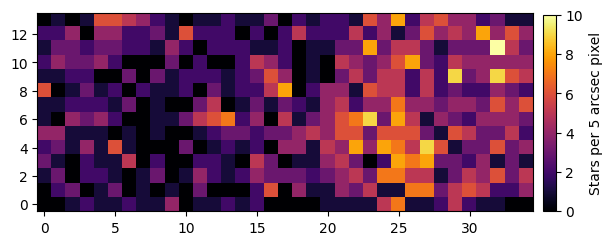

In [37]:
dx = 10*u.arcsec
h_fore_brick = star_density_color(fore_brick_all.catalog, ww_brick, dx=dx, size=(2.5*u.arcmin, 6*u.arcmin))

ax = plt.subplot()#projection=ww_brick)
im = ax.imshow(h_fore_brick, origin='lower', cmap='inferno', vmin=0, vmax=10)
cax = ax.inset_axes([1.02, 0., 0.025, 0.99])
cbar = plt.colorbar(im, cax=cax, label='Stars per 5 arcsec pixel')
#plt.colorbar(im, label='Stars per 5 arcsec pixel')

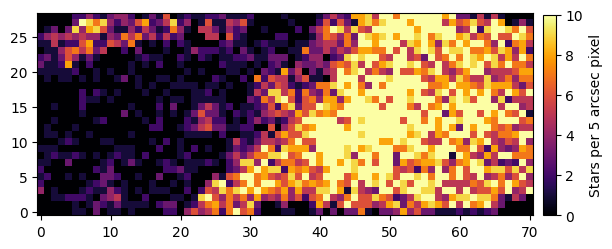

In [38]:
dx = 5*u.arcsec
h_cmz_brick = star_density_color(cmz_brick_all.catalog, ww_brick, dx=dx, size=(2.5*u.arcmin, 6*u.arcmin))

ax = plt.subplot()#projection=ww_brick)
im = ax.imshow(h_cmz_brick, origin='lower', cmap='inferno', vmin=0, vmax=10)
cax = ax.inset_axes([1.02, 0., 0.025, 0.99])
cbar = plt.colorbar(im, cax=cax, label='Stars per 5 arcsec pixel')
#plt.colorbar(im, label='Stars per 5 arcsec pixel')

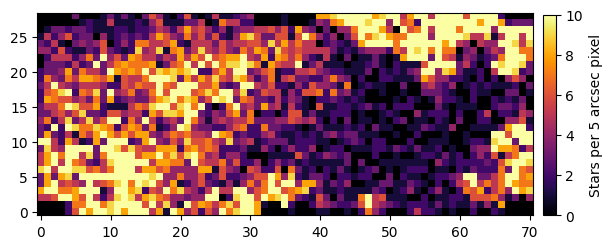

In [39]:
dx = 5*u.arcsec
h_cmz_brick = star_density_color(deep_brick_all.catalog, ww_brick, dx=dx, size=(2.5*u.arcmin, 6*u.arcmin))

ax = plt.subplot()#projection=ww_brick)
im = ax.imshow(h_cmz_brick, origin='lower', cmap='inferno', vmin=0, vmax=10)
cax = ax.inset_axes([1.02, 0., 0.025, 0.99])
cbar = plt.colorbar(im, cax=cax, label='Stars per 5 arcsec pixel')
#plt.colorbar(im, label='Stars per 5 arcsec pixel')

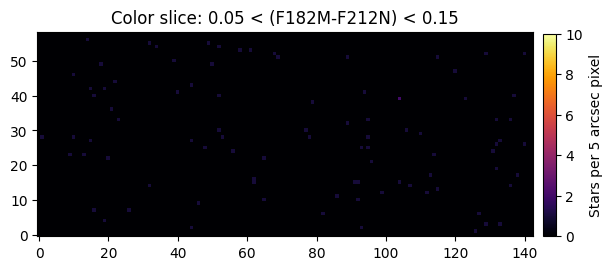

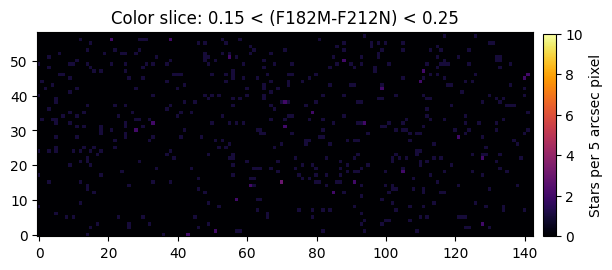

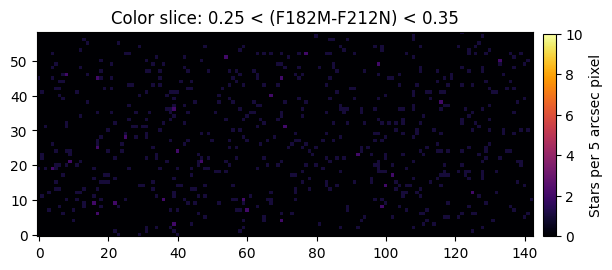

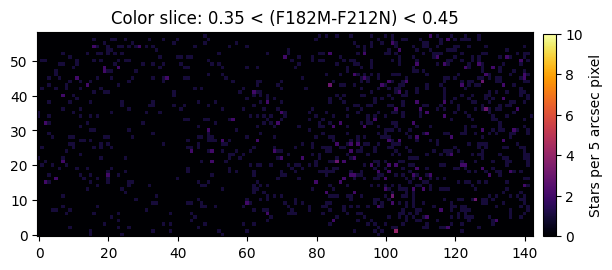

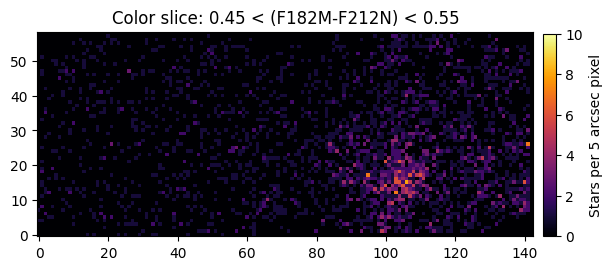

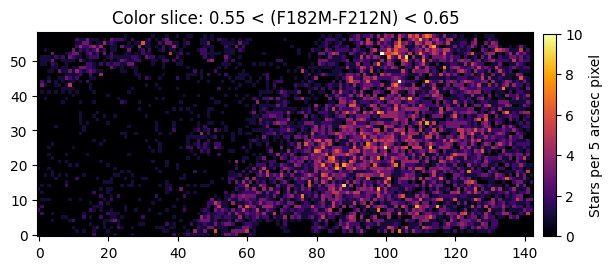

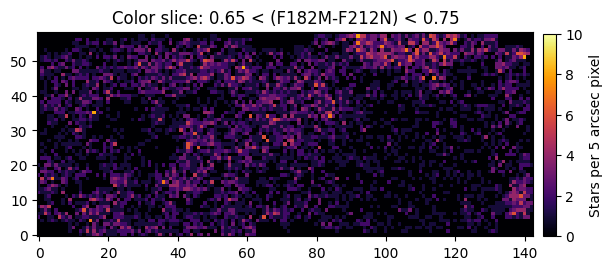

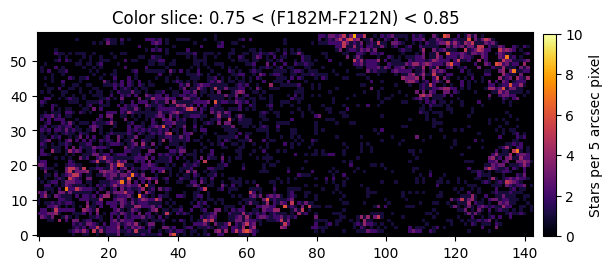

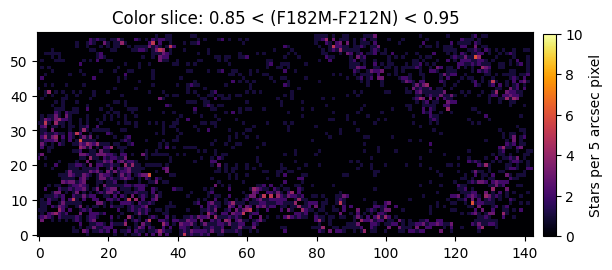

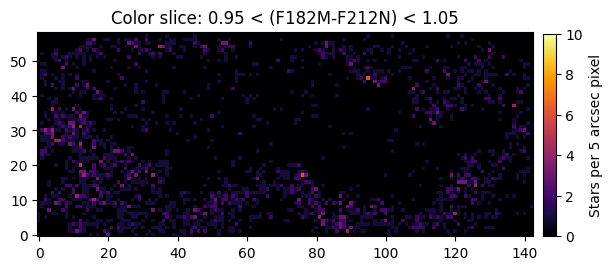

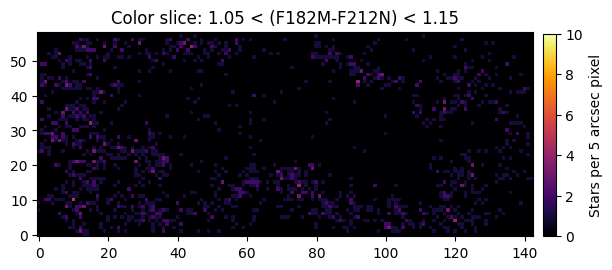

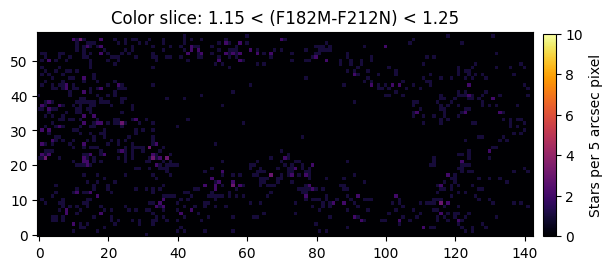

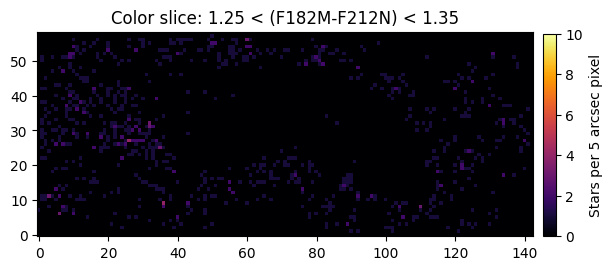

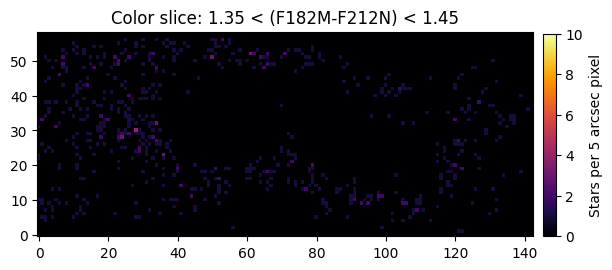

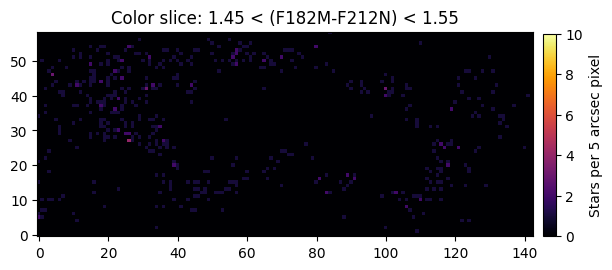

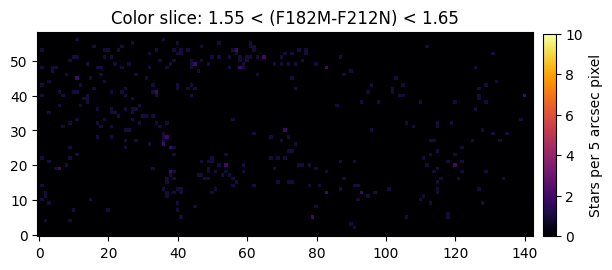

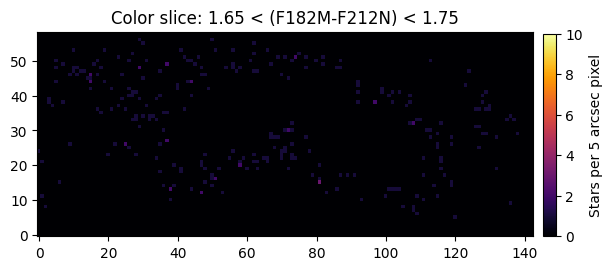

In [43]:
slices = [(0.05, 0.15), (0.15, 0.25), (0.25, 0.35), (0.35, 0.45), (0.45, 0.55), (0.55, 0.65), (0.65, 0.75), (0.75, 0.85), (0.85, 0.95), (0.95, 1.05), (1.05, 1.15), (1.15, 1.25), (1.25, 1.35), (1.35, 1.45), (1.45, 1.55), (1.55, 1.65), (1.65, 1.75)]

for sl in slices:
    mask_slice = np.logical_and(cat_brick.color('f182m', 'f212n') > sl[0], cat_brick.color('f182m', 'f212n') < sl[1])
    cat_slice = JWSTCatalog(cat_brick.catalog[mask_slice])
    dx = 2.5*u.arcsec
    h_slice = star_density_color(cat_slice.catalog, ww_brick, dx=dx, size=(2.5*u.arcmin, 6*u.arcmin))

    ax = plt.subplot()
    im = ax.imshow(h_slice, origin='lower', cmap='inferno', vmin=0, vmax=10)
    cax = ax.inset_axes([1.02, 0., 0.025, 0.99])
    cbar = plt.colorbar(im, cax=cax, label='Stars per 5 arcsec pixel')
    ax.set_title(f"Color slice: {sl[0]:.2f} < (F182M-F212N) < {sl[1]:.2f}")
    plt.show()